In [ ]:
import pandas as pd
from pc_utils import plot_pc
import glob

df_offsets = pd.read_csv(
    "data/data_from_nadara/nadara_yaw_misalignment_history.csv", sep=";"
)
sub_df = df_offsets[["Date", "Pampilhosa - PAP-17"]].dropna()

In [9]:



folder_path = "data/data_from_nadara/TENMIN/PPP_WTG17/"
files = glob.glob(folder_path + "*.parquet")
scada_df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

In [10]:
# Prepare sub_df (rename column)
sub_df = df_offsets[["Date", "Pampilhosa - PAP-17"]].dropna()
sub_df = sub_df.rename(columns={"Pampilhosa - PAP-17": "YawOffset"})

# Make sure Date columns are datetime (important!)
scada_df["Date"] = pd.to_datetime(scada_df["ts"])
sub_df["Date"] = pd.to_datetime(sub_df["Date"])

# Merge into main df
# Create mapping (date → offset)
mapping = sub_df.set_index(sub_df["Date"].dt.date)["YawOffset"]

# Apply to scada
scada_df["YawOffset"] = pd.to_datetime(scada_df["ts"]).dt.date.map(mapping)

In [11]:
scada_df = scada_df[scada_df["Power"] > 0]
scada_df["Power"] = scada_df["Power"] / 4500

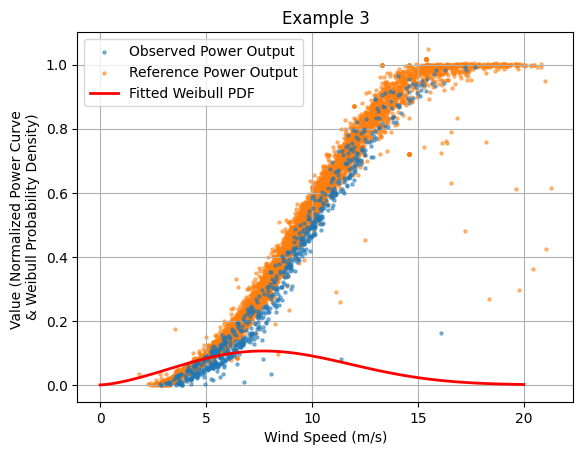

In [12]:
import matplotlib.pyplot as plt

mask = scada_df["YawOffset"].abs() > 8
mask_ref = scada_df["YawOffset"].abs() < 3
wind_speed = scada_df[mask]["WindSpeed"]
power_output = scada_df[mask]["Power"]
wind_speed_ref = scada_df[mask_ref]["WindSpeed"]
power_output_ref = scada_df[mask_ref]["Power"]
plot_pc(wind_speed, power_output, wind_speed_ref, power_output_ref, "Example 3", reveres_zorder= True)

Loss = 0.101


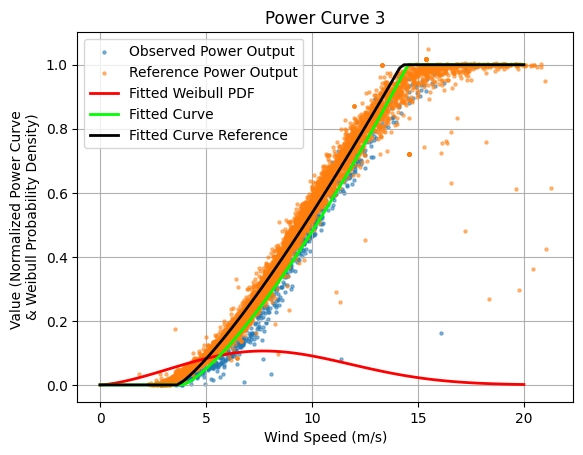

In [13]:
plot_pc(
    wind_speed,
    power_output,
    wind_speed_ref,
    power_output_ref,
    "Power Curve 3",
    plot_pc_fit=True,
)